=== CLASS IMBALANCE ANALYSIS ===
Total Transactions: 284807
Normal Transactions (Class 0): 284315
Fraudulent Transactions (Class 1): 492
Percentage of Fraud: 0.173%



/tmp/ipykernel_2031/2339089023.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='Amount', data=df, ax=ax1, palette='Set2')
/tmp/ipykernel_2031/2339089023.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['Normal', 'Fraud'])


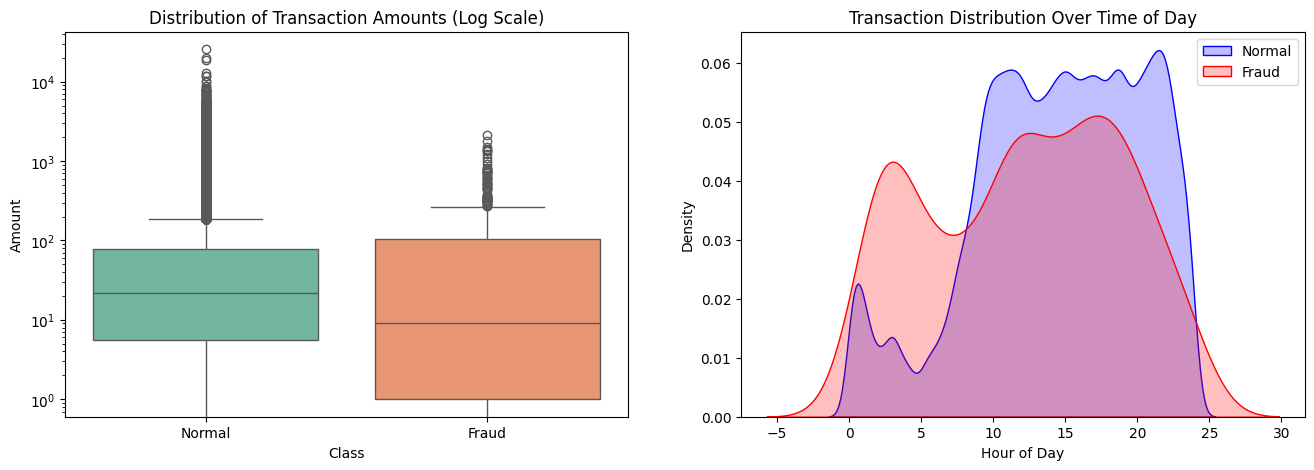

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE


file_path = '/content/drive/MyDrive/Colab Notebooks/OIBSIPDataAnalytics-L1-EDARetailSales/creditcard.csv'
df = pd.read_csv(file_path)

# --- CHECKLIST: Load dataset and analyse class imbalance ---
total_tx = len(df)
fraud_tx = df['Class'].sum()
normal_tx = total_tx - fraud_tx
fraud_percentage = (fraud_tx / total_tx) * 100

print("=== CLASS IMBALANCE ANALYSIS ===")
print(f"Total Transactions: {total_tx}")
print(f"Normal Transactions (Class 0): {normal_tx}")
print(f"Fraudulent Transactions (Class 1): {fraud_tx}")
print(f"Percentage of Fraud: {fraud_percentage:.3f}%\n")

# --- CHECKLIST: EDA (Transaction Amounts & Time Analysis) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Distribution of Transaction Amounts (using log scale due to massive outliers)
sns.boxplot(x='Class', y='Amount', data=df, ax=ax1, palette='Set2')
ax1.set_yscale('log')
ax1.set_title('Distribution of Transaction Amounts (Log Scale)')
ax1.set_xticklabels(['Normal', 'Fraud'])

# Time of day analysis (converting seconds to hour of day 0-23)
df['Hour'] = (df['Time'] / 3600) % 24
sns.kdeplot(df[df['Class'] == 0]['Hour'], label='Normal', fill=True, ax=ax2, color='blue')
sns.kdeplot(df[df['Class'] == 1]['Hour'], label='Fraud', fill=True, ax=ax2, color='red')
ax2.set_title('Transaction Distribution Over Time of Day')
ax2.set_xlabel('Hour of Day')
plt.legend()
plt.show()

### Why Standard Accuracy is a Misleading Metric
In this dataset, 99.828% of the transactions are legitimate. If we create a basic dummy model that blindly classifies *every single transaction* as non-fraudulent (Class 0), that model will achieve a stellar **99.828% accuracy**.

However, it will miss 100% of actual fraud cases, causing catastrophic financial losses. Accuracy treats all misclassifications equally, which fails completely when the cost of missing a rare positive case is incredibly high.

In [3]:
# Separate features and target
X = df.drop(['Class', 'Hour'], axis=1)
y = df['Class']

# --- CHECKLIST: Train/test split with stratification ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- CHECKLIST: Apply SMOTE oversampling ---
print(f"Before SMOTE - Training Class Count: {np.bincount(y_train)}")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"After SMOTE  - Training Class Count: {np.bincount(y_train_res)}")

Before SMOTE - Training Class Count: [227451    394]
After SMOTE  - Training Class Count: [227451 227451]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



================ LOGISTIC REGRESSION REPORT ================
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.12      0.90      0.21        98

    accuracy                           0.99     56962
   macro avg       0.56      0.94      0.60     56962
weighted avg       1.00      0.99      0.99     56962

AUC-ROC Score: 0.9760

================ RANDOM FOREST REPORT ================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.51      0.89      0.65        98

    accuracy                           1.00     56962
   macro avg       0.76      0.94      0.83     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC Score: 0.9853


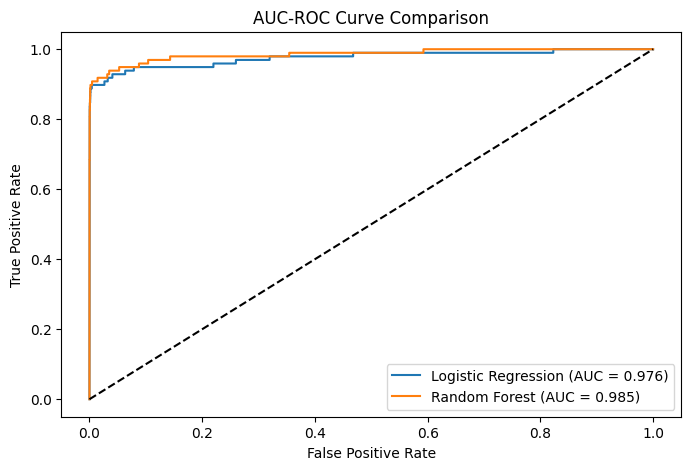

In [4]:
# --- CHECKLIST: Train at least 2 models ---
lr_model = LogisticRegression(max_iter=1000, random_state=42)
# Using restricted max_depth and estimators for memory safety in Google Colab environment
rf_model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)

# Fit models on SMOTE balanced training data
lr_model.fit(X_train_res, y_train_res)
rf_model.fit(X_train_res, y_train_res)

# Predict probabilities and standard labels
lr_probs = lr_model.predict_proba(X_test)[:, 1]
rf_probs = rf_model.predict_proba(X_test)[:, 1]

lr_preds = lr_model.predict(X_test)
rf_preds = rf_model.predict(X_test)

# --- CHECKLIST: Evaluate using Precision, Recall, F1, and AUC-ROC ---
for name, preds, probs in [('Logistic Regression', lr_preds, lr_probs), ('Random Forest', rf_preds, rf_probs)]:
    print(f"\n================ {name.upper()} REPORT ================")
    print(classification_report(y_test, preds))
    print(f"AUC-ROC Score: {roc_auc_score(y_test, probs):.4f}")

# Plot ROC Curves
plt.figure(figsize=(8, 5))
for name, probs in [('Logistic Regression', lr_probs), ('Random Forest', rf_probs)]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, probs):.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.title('AUC-ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

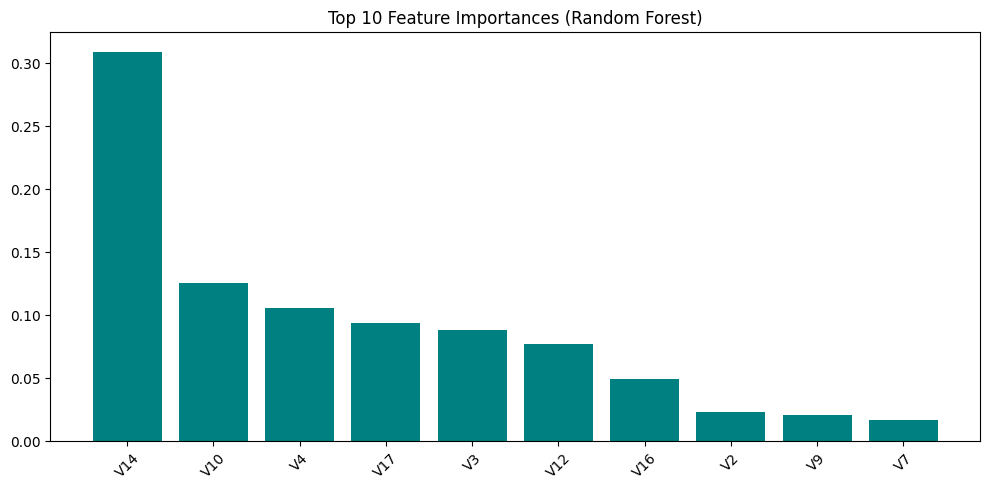

In [5]:
# --- CHECKLIST: Feature importance chart (Random Forest) ---
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.title("Top 10 Feature Importances (Random Forest)")
plt.bar(range(10), importances[indices[:10]], align="center", color="teal")
plt.xticks(range(10), [X.columns[i] for i in indices[:10]], rotation=45)
plt.tight_layout()
plt.show()

### Precision vs. Recall Trade-off
* **Recall Matters Most:** In fraud detection, **Recall** is prioritized over Precision. High Recall means catching the maximum amount of true fraud transactions. If Precision drops slightly, it simply means clean customers might experience a temporary false alarm or transaction verification alert. While inconvenient, this is significantly better than letting a massive fraudulent charge pass undetected (low Recall).

### Scalability Discussion (1 Million Transactions/Hour)
* **Model Suitability:** 1 million transactions per hour equals roughly 278 transactions per second (TPS). While Random Forest yielded strong metric performance, its prediction throughput is limited during heavy volume spikes. For low-latency production pipelines, optimized gradient boost engines (like LightGBM) or scaled Logistic Regression pipelines are preferred.
* **Pipeline Infrastructure:** Live deployment requires serving models via sub-100ms microservice architectures (e.g., using FastAPI and ONNX runtimes), streaming event platforms like Apache Kafka, and a dynamic real-time feature engine store (like Feast) to calculate running user-profile aggregations instantly.